<a href="https://colab.research.google.com/github/SHRESHTH121/HandsOnMachineLearning/blob/main/SVM_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.svm import LinearSVR
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# **Linear SVM regression**

In [3]:
np.random.seed(42)
X = 2 * np.random.rand(50, 1)
y = 4 + 3 * X[:, 0] + np.random.randn(50)

svm_reg = make_pipeline(StandardScaler(),
                        LinearSVR(epsilon=0.5, dual=True, random_state=42))
svm_reg.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr',
                 LinearSVR(dual=True, epsilon=0.5, random_state=42))])

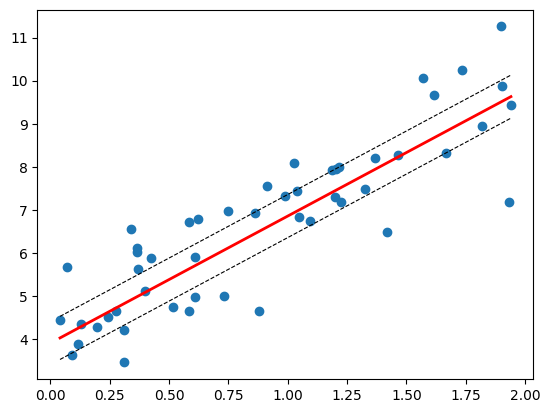

In [11]:
plt.scatter(X, y)
X_sorted = np.sort(X, axis=0)
plt.plot(X_sorted, svm_reg.predict(X_sorted), color='red', linewidth=2)
plt.plot(X_sorted, svm_reg.predict(X_sorted)+0.5, color='black', linestyle='--', linewidth=0.8)
plt.plot(X_sorted, svm_reg.predict(X_sorted)-0.5, color='black', linestyle='--', linewidth=0.8)
plt.show()

# **Non-linear SVM regression**

In [12]:
from sklearn.svm import SVR

# these 3 lines generate a simple quadratic dataset
np.random.seed(42)
X = 2 * np.random.rand(50, 1) - 1
y = 0.2 + 0.1 * X[:, 0] + 0.5 * X[:, 0] ** 2 + np.random.randn(50) / 10

svm_poly_reg = make_pipeline(StandardScaler(),
                             SVR(kernel="poly", degree=2, C=0.01, epsilon=0.1))
svm_poly_reg.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=0.01, degree=2, kernel='poly'))])

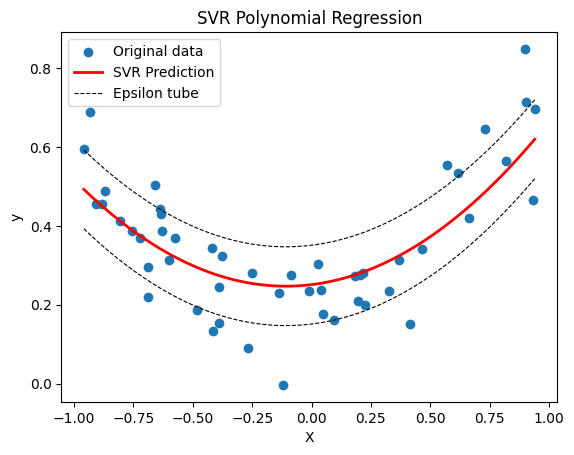

In [13]:
X_new = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_new_pred = svm_poly_reg.predict(X_new)

plt.scatter(X, y, label='Original data')
plt.plot(X_new, y_new_pred, color='red', linewidth=2, label='SVR Prediction')
plt.plot(X_new, y_new_pred + 0.1, color='black', linestyle='--', linewidth=0.8, label='Epsilon tube')
plt.plot(X_new, y_new_pred - 0.1, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('X')
plt.ylabel('y')
plt.title('SVR Polynomial Regression')
plt.legend()
plt.show()